<a href="https://colab.research.google.com/github/saramaknojia94-ux/readmission-dashboard/blob/main/Readmission_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install kagglehub
!pip install kagglehub

# Import and download the dataset
import kagglehub

path = kagglehub.dataset_download("brandao/diabetes")
print("Path to dataset files:", path)

100%|██████████| 4.41M/4.41M [00:00<00:00, 107MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/brandao/diabetes/versions/1


In [ ]:
import pandas as pd
# Load the data from the downloaded path
df = pd.read_csv(path + '/diabetic_data.csv')
print("Data loaded!")
print("Shape:", df.shape)
df.head()

Data loaded!
Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
print("=== COLUMN NAMES ===")
print(df.columns.tolist())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== READMISSION BREAKDOWN ===")
print(df['readmitted'].value_counts())

=== COLUMN NAMES ===
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

=== MISSING VALUES ===
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
a

In [ ]:
# dropping columns where more than 80% of data was missing
# also removing payer_code and medical_specialty - not relevant to readmission
cols_to_drop = ['weight', 'payer_code', 'max_glu_serum',
                'A1Cresult', 'medical_specialty']
df = df.drop(columns=cols_to_drop, errors='ignore')

# keeping only first hospital visit per patient
df = df.drop_duplicates(subset='patient_nbr', keep='first')

# flagging readmission as 1 or 0 for easier analysis
df['readmitted_flag'] = df['readmitted'].apply(
    lambda x: 0 if x == 'NO' else 1)

print("cleaned. new shape:", df.shape)
print(df['readmitted_flag'].value_counts())
print(f"overall readmission rate: {df['readmitted_flag'].mean()*100:.1f}%")

cleaned. new shape: (71518, 46)
readmitted_flag
0    42985
1    28533
Name: count, dtype: int64
overall readmission rate: 39.9%


Now that the data is clean, I want to understand what factors are
associated with higher readmission rates. Starting with age,
time in hospital, and number of diagnoses since those felt most
clinically relevant.

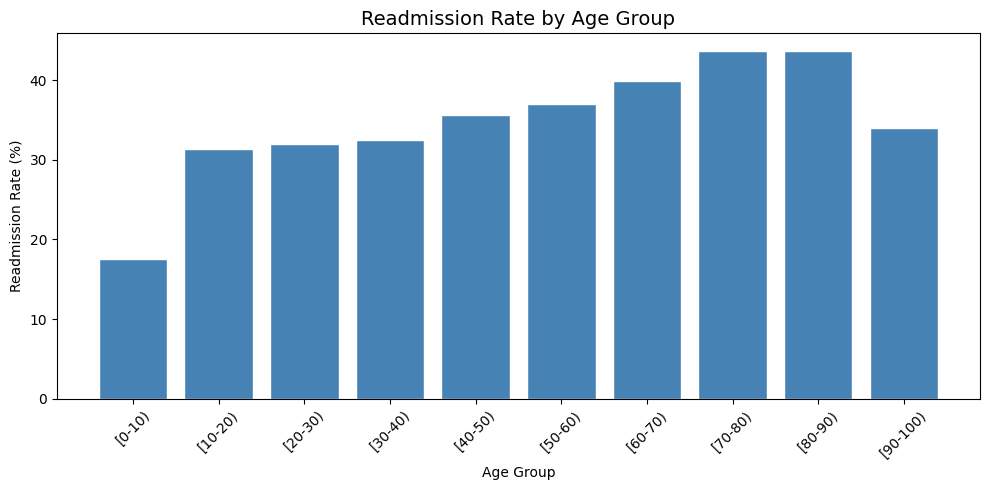

age
[0-10)      17.5
[10-20)     31.4
[20-30)     31.9
[30-40)     32.5
[40-50)     35.6
[50-60)     37.0
[60-70)     39.9
[70-80)     43.7
[80-90)     43.7
[90-100)    34.0
Name: readmitted_flag, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# looking at readmission rate by age group
age_readmit = df.groupby('age')['readmitted_flag'].mean().sort_index() * 100

plt.figure(figsize=(10, 5))
plt.bar(age_readmit.index, age_readmit.values, color='steelblue', edgecolor='white')
plt.title('Readmission Rate by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('readmission_by_age.png', dpi=150)
plt.show()

print(age_readmit.round(1))

Older patients (70-90) show significantly higher readmission rates
at 43.7% compared to younger groups. This aligns with clinical
expectations — older patients typically have more comorbidities
and longer recovery times.

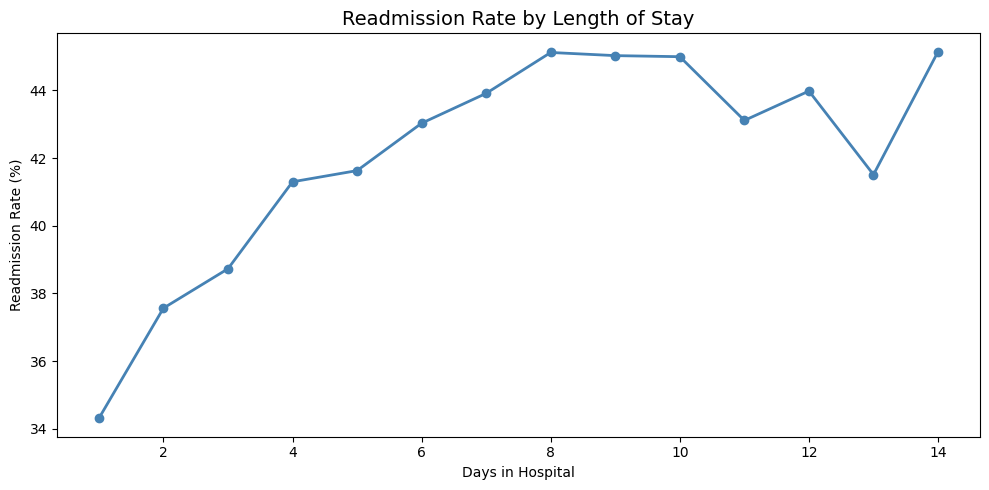

time_in_hospital
1     34.3
2     37.6
3     38.7
4     41.3
5     41.6
6     43.0
7     43.9
8     45.1
9     45.0
10    45.0
11    43.1
12    44.0
13    41.5
14    45.1
Name: readmitted_flag, dtype: float64


In [ ]:
# checking if longer hospital stays correlate with readmission
time_readmit = df.groupby('time_in_hospital')['readmitted_flag'].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(time_readmit.index, time_readmit.values,
         marker='o', color='steelblue', linewidth=2)
plt.title('Readmission Rate by Length of Stay', fontsize=14)
plt.xlabel('Days in Hospital')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.savefig('readmission_by_los.png', dpi=150)
plt.show()

print(time_readmit.round(1))

There's a clear pattern here — longer hospital stays are associated
with higher readmission rates. Patients staying 8 or more days
had a readmission rate around 45%, compared to 34% for 1-day stays.
This could indicate that more complex cases are both harder to
treat AND more likely to return.

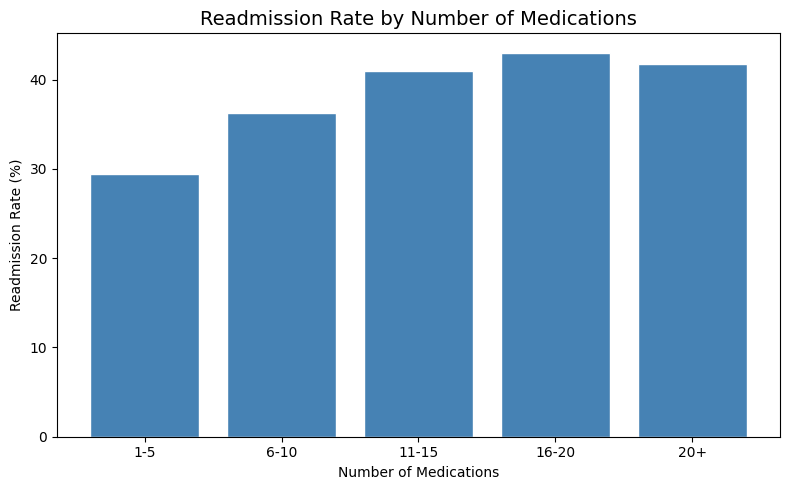

med_bucket
1-5      29.5
6-10     36.3
11-15    41.0
16-20    43.0
20+      41.8
Name: readmitted_flag, dtype: float64


In [ ]:
# grouping medications into buckets to see if more meds = higher readmission
df['med_bucket'] = pd.cut(df['num_medications'],
                           bins=[0, 5, 10, 15, 20, 100],
                           labels=['1-5', '6-10', '11-15', '16-20', '20+'])

med_readmit = df.groupby('med_bucket', observed=True)['readmitted_flag'].mean() * 100

plt.figure(figsize=(8, 5))
plt.bar(med_readmit.index, med_readmit.values, color='steelblue', edgecolor='white')
plt.title('Readmission Rate by Number of Medications', fontsize=14)
plt.xlabel('Number of Medications')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.savefig('readmission_by_meds.png', dpi=150)
plt.show()

print(med_readmit.round(1))

Patients managing 16 or more medications had readmission rates
nearly 15 points higher than those on fewer medications. This
suggests medication complexity is a meaningful risk factor —
possibly worth flagging in a clinical intervention program.

In [ ]:
# building a summary table to use in Tableau
summary = pd.DataFrame({
    'metric': [
        'Overall Readmission Rate',
        'Readmission Rate Age 70-80',
        'Readmission Rate Age 80-90',
        'Readmission Rate 1-Day Stay',
        'Readmission Rate 8+ Day Stay',
        'Readmission Rate 1-5 Meds',
        'Readmission Rate 16-20 Meds'
    ],
    'value': [39.9, 43.7, 43.7, 34.3, 45.1, 29.5, 43.0]
})

# also export the full cleaned dataset for tableau
df.to_csv('readmission_cleaned.csv', index=False)
summary.to_csv('readmission_summary.csv', index=False)

print("exported. files ready for tableau.")
print(summary)

exported. files ready for tableau.
                         metric  value
0      Overall Readmission Rate   39.9
1    Readmission Rate Age 70-80   43.7
2    Readmission Rate Age 80-90   43.7
3   Readmission Rate 1-Day Stay   34.3
4  Readmission Rate 8+ Day Stay   45.1
5     Readmission Rate 1-5 Meds   29.5
6   Readmission Rate 16-20 Meds   43.0


In [ ]:
from google.colab import files

files.download('readmission_cleaned.csv')
files.download('readmission_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>